In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') #turn off warning 

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

In [154]:
df_ori = pd.read_csv('seed_14399.csv')

# Cek dulu berapa unique customer
print(f"Total transaksi  : {len(df_ori):,}")
print(f"Unique customer  : {df_ori['Customer_ID'].nunique():,}")
print(f"Avg transaksi/customer: {len(df_ori)/df_ori['Customer_ID'].nunique():.1f}x")

Total transaksi  : 14,399
Unique customer  : 4,824
Avg transaksi/customer: 3.0x


In [155]:
df_ori.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

In [156]:
df_ori.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14399 entries, 0 to 14398
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  14399 non-null  object 
 1   Customer_ID               14399 non-null  object 
 2   Date                      14399 non-null  object 
 3   Age                       14399 non-null  int64  
 4   Gender                    14399 non-null  object 
 5   City                      14399 non-null  object 
 6   Product_Category          14399 non-null  object 
 7   Unit_Price                14399 non-null  float64
 8   Quantity                  14399 non-null  int64  
 9   Discount_Amount           14399 non-null  float64
 10  Total_Amount              14399 non-null  float64
 11  Payment_Method            14399 non-null  object 
 12  Device_Type               14399 non-null  object 
 13  Session_Duration_Minutes  14399 non-null  int64  
 14  Pages_

In [157]:
# ── AGREGASI per CUSTOMER ─────────────────────────────────────────────────────
df_customer = df_ori.groupby('Customer_ID').agg(

    # Demografi — ambil nilai pertama (sama untuk 1 customer)
    Age                    = ('Age',                    'first'),
    Gender                 = ('Gender',                 'first'),
    City                   = ('City',                   'first'),

    # Behavior transaksi — SUM & MEAN
    Total_Transactions     = ('Order_ID',               'count'),   # frekuensi beli
    Total_Spend            = ('Total_Amount',            'sum'),     # total belanja
    Avg_Order_Value        = ('Total_Amount',            'mean'),    # rata2 per transaksi
    Total_Quantity         = ('Quantity',                'sum'),     # total item dibeli
    Avg_Quantity_per_Order = ('Quantity',                'mean'),
    Total_Discount         = ('Discount_Amount',         'sum'),
    Avg_Discount_per_Order = ('Discount_Amount',         'mean'),

    # Engagement — MEAN lebih representatif
    Avg_Session_Duration   = ('Session_Duration_Minutes','mean'),
    Avg_Pages_Viewed       = ('Pages_Viewed',            'mean'),

    # Kepuasan & loyalitas
    Avg_Customer_Rating    = ('Customer_Rating',         'mean'),
    Avg_Delivery_Time      = ('Delivery_Time_Days',      'mean'),
    Is_Returning_Customer  = ('Is_Returning_Customer',   'max'),    # pernah return = 1

    # Preferensi — mode (kategori paling sering)
    Fav_Payment_Method     = ('Payment_Method',          lambda x: x.mode()[0]),
    Fav_Device_Type        = ('Device_Type',             lambda x: x.mode()[0]),
    Fav_Product_Category   = ('Product_Category',        lambda x: x.mode()[0]),

).reset_index()

print(f"\nShape setelah agregasi: {df_customer.shape}")
print(f"Sekarang 1 baris = 1 customer ✅")
df_customer.head()


Shape setelah agregasi: (4824, 19)
Sekarang 1 baris = 1 customer ✅


,Customer_ID,Age,Gender,City,Total_Transactions,Total_Spend,Avg_Order_Value,Total_Quantity,Avg_Quantity_per_Order,Total_Discount,Avg_Discount_per_Order,Avg_Session_Duration,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time,Is_Returning_Customer,Fav_Payment_Method,Fav_Device_Type,Fav_Product_Category
0,CUST_00001,40,Male,Ankara,3,2199.63,733.210000,7,2.333333,138.05,46.016667,14.333333,9.000000,3.333333,9.333333,True,Credit Card,Mobile,Books
1,CUST_00002,33,Male,Istanbul,2,809.90,404.950000,8,4.000000,71.05,35.525000,15.000000,10.000000,4.000000,5.000000,True,Credit Card,Desktop,Beauty
2,CUST_00003,42,Male,Konya,2,3030.81,1515.405000,7,3.500000,0.00,0.000000,10.500000,8.500000,3.500000,6.000000,True,Credit Card,Desktop,Home & Garden
3,CUST_00005,32,Male,Ankara,3,2422.73,807.576667,8,2.666667,0.00,0.000000,12.666667,9.333333,3.666667,5.666667,True,Credit Card,Mobile,Fashion
4,CUST_00006,32,Female,Istanbul,3,1245.83,415.276667,9,3.000000,12.77,4.256667,16.000000,9.333333,4.333333,7.666667,True,Credit Card,Mobile,Beauty


## Feature Engineering

In [158]:
# ── FEATURE ENGINEERING di level customer ────────────────────────────────────
# Fitur turunan yang lebih meaningful di level customer

# Discount sensitivity — total diskon / total spend
df_customer['Discount_Rate'] = (
    df_customer['Total_Discount'] / 
    (df_customer['Total_Spend'] + df_customer['Total_Discount'])
).fillna(0)

# Engagement score per customer
df_customer['Engagement_Score'] = (
    df_customer['Avg_Session_Duration'] * df_customer['Avg_Pages_Viewed']
)

# Avg item price per customer
df_customer['Avg_Item_Price'] = (
    df_customer['Total_Spend'] / df_customer['Total_Quantity']
).fillna(0)

# Purchase frequency category (opsional, bisa jadi fitur tambahan)
df_customer['Purchase_Frequency'] = df_customer['Total_Transactions']

print("Fitur customer-level siap!")
print(df_customer.columns.tolist())
print(f"\nStatistik transaksi per customer:")
print(df_customer['Total_Transactions'].describe())

Fitur customer-level siap!
['Customer_ID', 'Age', 'Gender', 'City', 'Total_Transactions', 'Total_Spend', 'Avg_Order_Value', 'Total_Quantity', 'Avg_Quantity_per_Order', 'Total_Discount', 'Avg_Discount_per_Order', 'Avg_Session_Duration', 'Avg_Pages_Viewed', 'Avg_Customer_Rating', 'Avg_Delivery_Time', 'Is_Returning_Customer', 'Fav_Payment_Method', 'Fav_Device_Type', 'Fav_Product_Category', 'Discount_Rate', 'Engagement_Score', 'Avg_Item_Price', 'Purchase_Frequency']

Statistik transaksi per customer:
count    4824.000000
mean        2.984867
std         1.902882
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        10.000000
Name: Total_Transactions, dtype: float64


In [159]:
df_customer.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Total_Transactions',
       'Total_Spend', 'Avg_Order_Value', 'Total_Quantity',
       'Avg_Quantity_per_Order', 'Total_Discount', 'Avg_Discount_per_Order',
       'Avg_Session_Duration', 'Avg_Pages_Viewed', 'Avg_Customer_Rating',
       'Avg_Delivery_Time', 'Is_Returning_Customer', 'Fav_Payment_Method',
       'Fav_Device_Type', 'Fav_Product_Category', 'Discount_Rate',
       'Engagement_Score', 'Avg_Item_Price', 'Purchase_Frequency'],
      dtype='object')

In [160]:
# ── 1. COPY dataframe ─────────────────────────────────────────────────────────
df = df_customer.copy()

# ── 2. DROP kolom tidak relevan ───────────────────────────────────────────────
cols_drop = ['Customer_ID', 'City', 'Gender']
df.drop(columns=cols_drop, inplace=True)

print("Shape setelah drop:", df.shape)
print(df.dtypes)

Shape setelah drop: (4824, 20)
Age                         int64
Total_Transactions          int64
Total_Spend               float64
Avg_Order_Value           float64
Total_Quantity              int64
Avg_Quantity_per_Order    float64
Total_Discount            float64
Avg_Discount_per_Order    float64
Avg_Session_Duration      float64
Avg_Pages_Viewed          float64
Avg_Customer_Rating       float64
Avg_Delivery_Time         float64
Is_Returning_Customer        bool
Fav_Payment_Method         object
Fav_Device_Type            object
Fav_Product_Category       object
Discount_Rate             float64
Engagement_Score          float64
Avg_Item_Price            float64
Purchase_Frequency          int64
dtype: object


In [161]:
# ── 4. ENCODE kolom kategorikal ───────────────────────────────────────────────
le = LabelEncoder()

cat_cols = ['Fav_Payment_Method', 'Fav_Device_Type', 'Fav_Product_Category']
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    print(f"{col}: {df[col].unique()} → encoded")

# Drop kolom aslinya
df.drop(columns=cat_cols, inplace=True)

# Encode Is_Returning_Customer (True/False → 1/0) kalau belum int
df['Is_Returning_Customer'] = df['Is_Returning_Customer'].astype(int)

df.head(3)

Fav_Payment_Method: ['Credit Card' 'Cash on Delivery' 'Debit Card' 'Digital Wallet'
 'Bank Transfer'] → encoded
Fav_Device_Type: ['Mobile' 'Desktop' 'Tablet'] → encoded
Fav_Product_Category: ['Books' 'Beauty' 'Home & Garden' 'Fashion' 'Sports' 'Electronics' 'Food'
 'Toys'] → encoded


,Age,Total_Transactions,Total_Spend,Avg_Order_Value,Total_Quantity,Avg_Quantity_per_Order,Total_Discount,Avg_Discount_per_Order,Avg_Session_Duration,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time,Is_Returning_Customer,Discount_Rate,Engagement_Score,Avg_Item_Price,Purchase_Frequency,Fav_Payment_Method_enc,Fav_Device_Type_enc,Fav_Product_Category_enc
0,40,3,2199.63,733.210,7,2.333333,138.05,46.016667,14.333333,9.0,3.333333,9.333333,1,0.059054,129.00,314.232857,3,2,1,1
1,33,2,809.90,404.950,8,4.000000,71.05,35.525000,15.000000,10.0,4.000000,5.000000,1,0.080652,150.00,101.237500,2,2,0,0
2,42,2,3030.81,1515.405,7,3.500000,0.00,0.000000,10.500000,8.5,3.500000,6.000000,1,0.000000,89.25,432.972857,2,2,0,5


In [162]:
# ── 5. HANDLE missing values & outliers ──────────────────────────────────────
# Cek missing
print("Missing values:\n", df.isnull().sum())

# Imputasi median untuk kolom numerik
df.fillna(df.median(numeric_only=True), inplace=True)

# IQR Clipping untuk outlier pada kolom penting
clip_cols = ['Total_Spend', 'Total_Quantity', 'Avg_Session_Duration',
             'Avg_Item_Price', 'Engagement_Score']

for col in clip_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("\nSetelah clipping — distribusi Total_Amount:")
print(df['Total_Spend'].describe())

Missing values:
 Age                         0
Total_Transactions          0
Total_Spend                 0
Avg_Order_Value             0
Total_Quantity              0
Avg_Quantity_per_Order      0
Total_Discount              0
Avg_Discount_per_Order      0
Avg_Session_Duration        0
Avg_Pages_Viewed            0
Avg_Customer_Rating         0
Avg_Delivery_Time           0
Is_Returning_Customer       0
Discount_Rate               0
Engagement_Score            0
Avg_Item_Price              0
Purchase_Frequency          0
Fav_Payment_Method_enc      0
Fav_Device_Type_enc         0
Fav_Product_Category_enc    0
dtype: int64

Setelah clipping — distribusi Total_Amount:
count     4824.000000
mean      3439.370893
std       3510.330610
min         14.280000
25%        717.277500
50%       2073.185000
75%       5153.425000
max      11807.646250
Name: Total_Spend, dtype: float64


In [163]:
# ── 6. STANDARDSCALER ─────────────────────────────────────────────────────────
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Data siap untuk PCA + K-Means!")
print("Shape final:", df_scaled.shape)
df_scaled.head(3)

Data siap untuk PCA + K-Means!
Shape final: (4824, 20)


,Age,Total_Transactions,Total_Spend,Avg_Order_Value,Total_Quantity,Avg_Quantity_per_Order,Total_Discount,Avg_Discount_per_Order,Avg_Session_Duration,Avg_Pages_Viewed,Avg_Customer_Rating,Avg_Delivery_Time,Is_Returning_Customer,Discount_Rate,Engagement_Score,Avg_Item_Price,Purchase_Frequency,Fav_Payment_Method_enc,Fav_Device_Type_enc,Fav_Product_Category_enc
0,0.447940,0.007953,-0.353206,-0.331090,-0.320048,-0.684005,-0.164721,-0.139999,-0.108696,0.006805,-0.705575,1.135842,0.320357,0.127571,-0.048548,-0.187590,0.007953,-0.038247,0.679628,-0.682742
1,-0.184023,-0.517620,-0.749144,-0.536784,-0.151019,0.985001,-0.315081,-0.205053,0.232366,0.634783,0.126596,-0.623077,0.320357,0.495567,0.695208,-0.855704,-0.517620,-0.038247,-1.109960,-1.135339
2,0.628502,-0.517620,-0.116400,0.159049,-0.320048,0.484299,-0.474530,-0.425328,-2.069806,-0.307184,-0.497533,-0.217173,0.320357,-0.878653,-1.456371,0.184868,-0.517620,-0.038247,-1.109960,1.127645


### PCA

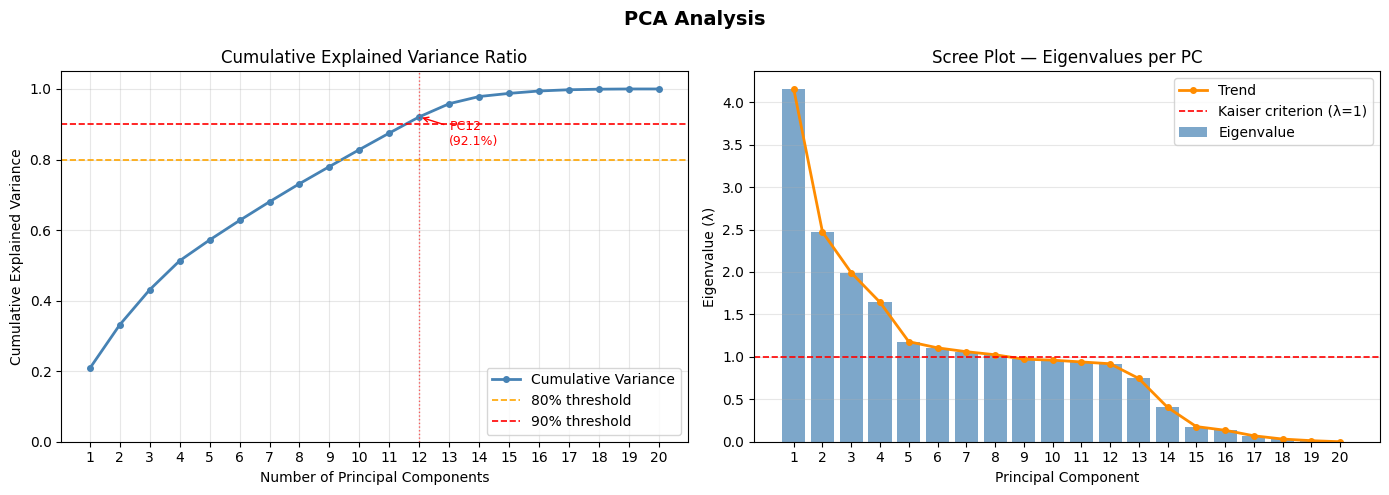

PC       Eigenvalue    Var Ratio   Cumulative
--------------------------------------------------
PC1          4.1564       20.8%       20.8%
PC2          2.4706       12.4%       33.1%
PC3          1.9914       10.0%       43.1%
PC4          1.6429        8.2%       51.3%
PC5          1.1791        5.9%       57.2%
PC6          1.1062        5.5%       62.7%
PC7          1.0610        5.3%       68.0%
PC8          1.0248        5.1%       73.1%
PC9          0.9728        4.9%       78.0%
PC10         0.9613        4.8%       82.8%
PC11         0.9401        4.7%       87.5%
PC12         0.9189        4.6%       92.1% ← 90%
PC13         0.7453        3.7%       95.8%
PC14         0.4054        2.0%       97.9%
PC15         0.1784        0.9%       98.8%
PC16         0.1353        0.7%       99.4%
PC17         0.0701        0.4%       99.8%
PC18         0.0316        0.2%       99.9%
PC19         0.0125        0.1%      100.0%
PC20         0.0000        0.0%      100.0%

Komponen optimal

In [164]:
# ── PCA ───────────────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA dengan semua komponen dulu
pca_full = PCA()
pca_full.fit(df_scaled)

explained_variance   = pca_full.explained_variance_ratio_
cumulative_variance  = np.cumsum(explained_variance)
eigenvalues          = pca_full.explained_variance_   # eigenvalues = variance tiap PC

n_components = len(explained_variance)
x_axis = np.arange(1, n_components + 1)

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Analysis', fontsize=14, fontweight='bold')

# --- Plot 1: Cumulative Explained Variance Ratio ---
axes[0].plot(x_axis, cumulative_variance, marker='o', markersize=4,
             color='steelblue', linewidth=2, label='Cumulative Variance')
axes[0].axhline(y=0.80, color='orange', linestyle='--', linewidth=1.2, label='80% threshold')
axes[0].axhline(y=0.90, color='red',    linestyle='--', linewidth=1.2, label='90% threshold')

# Tandai titik potong 90%
idx_90 = np.argmax(cumulative_variance >= 0.90)
axes[0].axvline(x=idx_90 + 1, color='red', linestyle=':', linewidth=1, alpha=0.6)
axes[0].annotate(f'PC{idx_90+1}\n({cumulative_variance[idx_90]:.1%})',
                 xy=(idx_90 + 1, cumulative_variance[idx_90]),
                 xytext=(idx_90 + 2, cumulative_variance[idx_90] - 0.08),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=9, color='red')

axes[0].set_title('Cumulative Explained Variance Ratio')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x_axis)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Eigenvalues (Scree Plot) ---
axes[1].bar(x_axis, eigenvalues, color='steelblue', alpha=0.7, label='Eigenvalue')
axes[1].plot(x_axis, eigenvalues, marker='o', markersize=4,
             color='darkorange', linewidth=2, label='Trend')
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='Kaiser criterion (λ=1)')

axes[1].set_title('Scree Plot — Eigenvalues per PC')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Eigenvalue (λ)')
axes[1].set_xticks(x_axis)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print("=" * 50)
print(f"{'PC':<6} {'Eigenvalue':>12} {'Var Ratio':>12} {'Cumulative':>12}")
print("-" * 50)
for i, (ev, vr, cv) in enumerate(zip(eigenvalues, explained_variance, cumulative_variance), 1):
    marker = " ← 90%" if i == idx_90 + 1 else ""
    print(f"PC{i:<4} {ev:>12.4f} {vr:>11.1%} {cv:>11.1%}{marker}")
print("=" * 50)
print(f"\nKomponen optimal (≥90% variance): {idx_90 + 1} PC")

In [165]:
# Coba bandingkan silhouette score dengan berbagai PC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []
pc_options = [3, 4, 5, 6, 7, 8]

for n_pc in pc_options:
    pca_test = PCA(n_components=n_pc, random_state=42)
    df_test  = pca_test.fit_transform(df_scaled)
    var_exp  = pca_test.explained_variance_ratio_.sum()
    
    sil_scores_k = {}
    for k in [3, 4]:
        km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        lbl = km.fit_predict(df_test)
        sil_scores_k[k] = silhouette_score(df_test, lbl)
    
    results.append({
        'n_PC'     : n_pc,
        'Var_Exp'  : f'{var_exp:.1%}',
        'Sil_K3'   : round(sil_scores_k[3], 4),
        'Sil_K4'   : round(sil_scores_k[4], 4),
    })

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))
print("\nPilih n_PC + K yang Sil Score-nya tertinggi!")

 n_PC Var_Exp  Sil_K3  Sil_K4
    3   43.1%  0.3458  0.3024
    4   51.3%  0.3003  0.2431
    5   57.2%  0.2702  0.2099
    6   62.7%  0.2374  0.1844
    7   68.0%  0.2129  0.1668
    8   73.1%  0.1940  0.1520

Pilih n_PC + K yang Sil Score-nya tertinggi!


In [166]:
# ── TRANSFORM dengan n_components optimal ─────────────────────────────────────
n_components_optimal = 3  # dari hasil 90% threshold
random_state = 72

pca = PCA(n_components=n_components_optimal, random_state=random_state)
df_pca = pca.fit_transform(df_scaled)

# Jadikan DataFrame biar lebih rapi
df_pca = pd.DataFrame(
    df_pca,
    columns=[f'PC{i+1}' for i in range(n_components_optimal)]
)

print(f"Shape setelah PCA: {df_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")
df_pca.head()

Shape setelah PCA: (4824, 3)
Total variance explained: 43.1%


,PC1,PC2,PC3
0,-0.526263,-0.376361,-0.036418
1,-1.028186,-0.320764,0.908141
2,-0.730951,0.155696,-2.020194
3,-0.640791,-0.707291,-0.537105
4,-0.830966,-1.091856,0.974447


In [167]:
# ── ELBOW METHOD ──────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

K_range = range(2, 11)
inertia   = []
sil_scores = []

print("Menghitung Elbow + Silhouette Score...")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
    labels = km.fit_predict(df_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_pca, labels))
    print(f"  K={k} | Inertia: {km.inertia_:,.1f} | Silhouette: {silhouette_score(df_pca, labels):.4f}")

print("Done!")

Menghitung Elbow + Silhouette Score...
  K=2 | Inertia: 28,126.4 | Silhouette: 0.3561
  K=3 | Inertia: 22,110.3 | Silhouette: 0.3461
  K=4 | Inertia: 17,142.6 | Silhouette: 0.3023
  K=5 | Inertia: 14,703.2 | Silhouette: 0.2844
  K=6 | Inertia: 12,918.0 | Silhouette: 0.2942
  K=7 | Inertia: 11,753.3 | Silhouette: 0.2586
  K=8 | Inertia: 10,929.2 | Silhouette: 0.2560
  K=9 | Inertia: 10,224.0 | Silhouette: 0.2627
  K=10 | Inertia: 9,488.5 | Silhouette: 0.2496
Done!


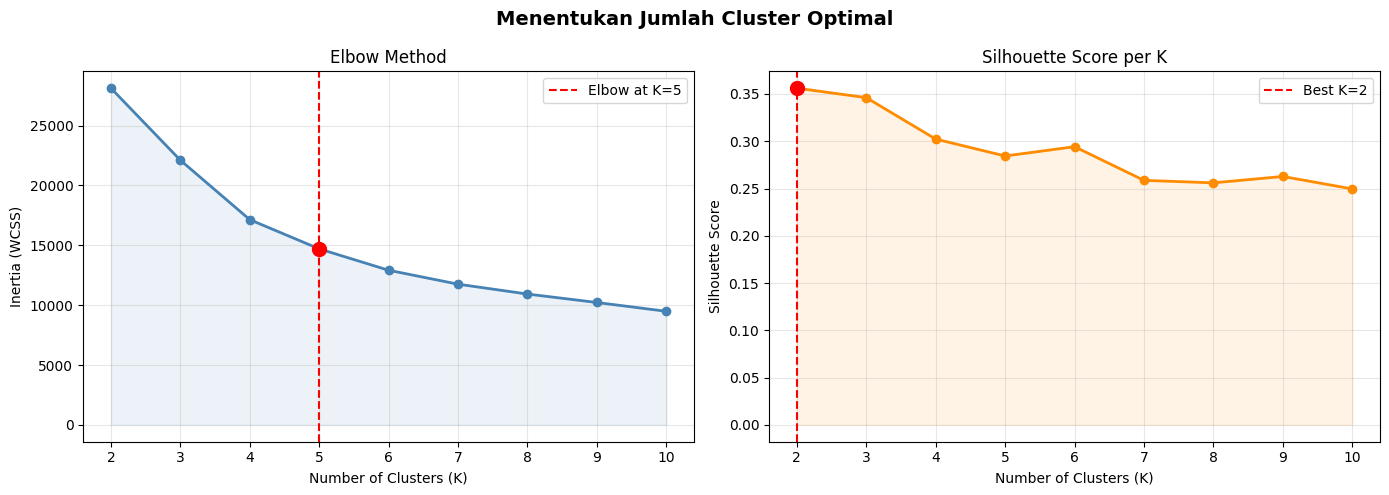


Elbow Method  → K optimal : 5
Silhouette Score → K optimal : 2 (score: 0.3561)


In [168]:
# ── PLOT 1: ELBOW METHOD ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')

k_list = list(K_range)

# Elbow curve
axes[0].plot(k_list, inertia, marker='o', markersize=6,
             color='steelblue', linewidth=2)
axes[0].fill_between(k_list, inertia, alpha=0.1, color='steelblue')

# Tandai elbow secara otomatis pakai metode jarak max ke garis lurus
from numpy.linalg import norm

p1  = np.array([k_list[0],  inertia[0]])
p2  = np.array([k_list[-1], inertia[-1]])
distances = []
for i, (k, val) in enumerate(zip(k_list, inertia)):
    p  = np.array([k, val])
    d  = norm(np.cross(p2 - p1, p1 - p)) / norm(p2 - p1)
    distances.append(d)

elbow_k = k_list[np.argmax(distances)]
elbow_inertia = inertia[np.argmax(distances)]
axes[0].axvline(x=elbow_k, color='red', linestyle='--', linewidth=1.5,
                label=f'Elbow at K={elbow_k}')
axes[0].scatter([elbow_k], [elbow_inertia], color='red', s=100, zorder=5)

axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(k_list)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── PLOT 2: SILHOUETTE SCORE ──────────────────────────────────────────────────
best_k_sil = k_list[np.argmax(sil_scores)]

axes[1].plot(k_list, sil_scores, marker='o', markersize=6,
             color='darkorange', linewidth=2)
axes[1].fill_between(k_list, sil_scores, alpha=0.1, color='darkorange')
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', linewidth=1.5,
                label=f'Best K={best_k_sil}')
axes[1].scatter([best_k_sil], [max(sil_scores)], color='red', s=100, zorder=5)

axes[1].set_title('Silhouette Score per K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_list)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette_score.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nElbow Method  → K optimal : {elbow_k}")
print(f"Silhouette Score → K optimal : {best_k_sil} (score: {max(sil_scores):.4f})")

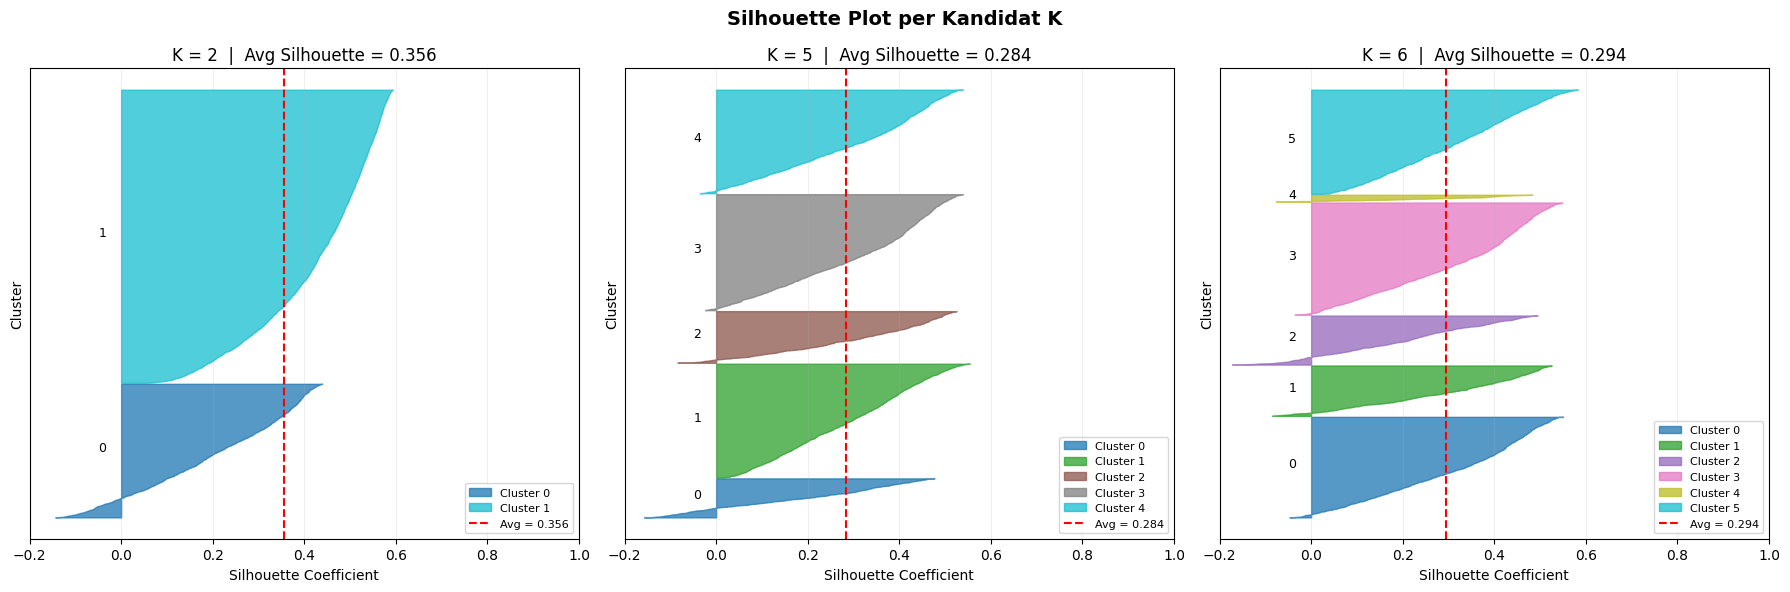

In [169]:
# ── PLOT 3: SILHOUETTE PLOT per K ─────────────────────────────────────────────
# Plot silhouette diagram untuk K kandidat (elbow & silhouette score)
candidates = sorted(set([elbow_k, best_k_sil, elbow_k + 1]))  # 2-3 kandidat
n_candidates = len(candidates)

fig, axes = plt.subplots(1, n_candidates, figsize=(6 * n_candidates, 6))
if n_candidates == 1:
    axes = [axes]

fig.suptitle('Silhouette Plot per Kandidat K', fontsize=14, fontweight='bold')

for ax, k in zip(axes, candidates):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
    labels   = km.fit_predict(df_pca)
    sil_vals = silhouette_samples(df_pca, labels)
    sil_avg  = silhouette_score(df_pca, labels)

    y_lower = 10
    colors = cm.tab10(np.linspace(0, 1, k))

    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size_i      = cluster_sil.shape[0]
        y_upper     = y_lower + size_i

        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_sil,
                         alpha=0.75, color=colors[i],
                         label=f'Cluster {i}')
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5,
               label=f'Avg = {sil_avg:.3f}')

    ax.set_title(f'K = {k}  |  Avg Silhouette = {sil_avg:.3f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_xlim([-0.2, 1.0])
    ax.set_yticks([])
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [170]:
# ── SUMMARY KEPUTUSAN ─────────────────────────────────────────────────────────
print("=" * 55)
print("RINGKASAN PENENTUAN K OPTIMAL")
print("=" * 55)
print(f"{'Metode':<25} {'K Optimal':>10} {'Nilai':>15}")
print("-" * 55)
print(f"{'Elbow Method':<25} {'K='+str(elbow_k):>10} {'(lihat plot)':>15}")
print(f"{'Silhouette Score':<25} {'K='+str(best_k_sil):>10} {max(sil_scores):>15.4f}")
print("-" * 55)
print(f"\nRekomendasi final → K = {best_k_sil}")
print("(konfirmasi dengan silhouette plot — pilih K yang")
print(" cluster-nya paling seragam & di atas garis merah)")
print("=" * 55)

RINGKASAN PENENTUAN K OPTIMAL
Metode                     K Optimal           Nilai
-------------------------------------------------------
Elbow Method                     K=5    (lihat plot)
Silhouette Score                 K=2          0.3561
-------------------------------------------------------

Rekomendasi final → K = 2
(konfirmasi dengan silhouette plot — pilih K yang
 cluster-nya paling seragam & di atas garis merah)


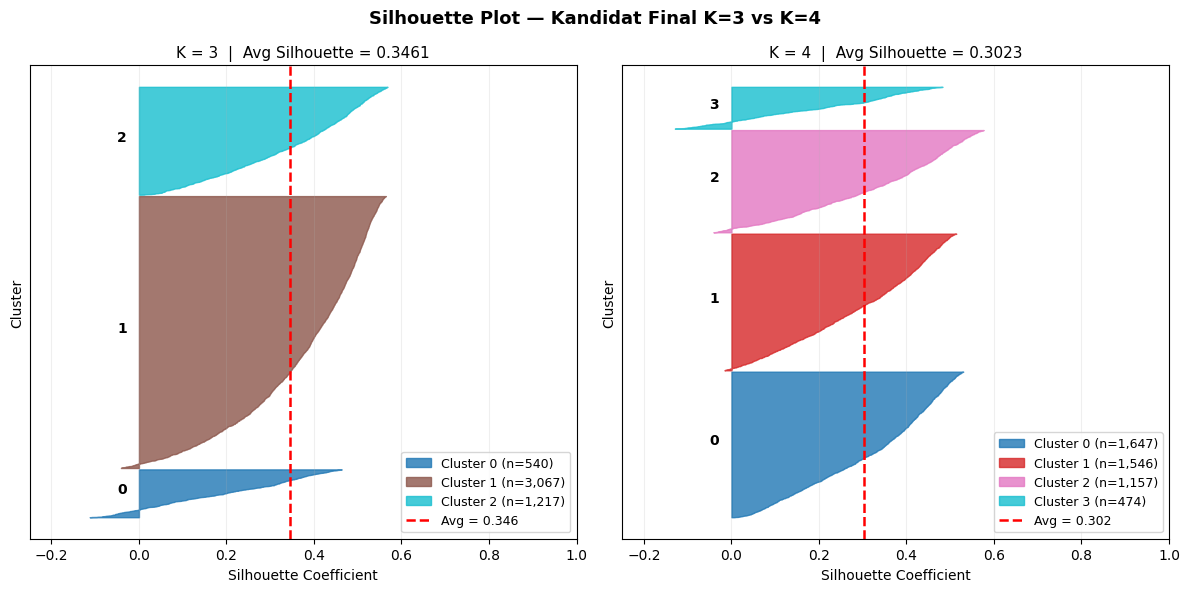

K        Silhouette Score     Rekomendasi
---------------------------------------------
K=2                0.3561                
K=3                0.3461      ← kandidat
K=4                0.3023      ← kandidat
K=6                0.2942                


In [171]:
# ── CEK SILHOUETTE PLOT K=3 dan K=4 ──────────────────────────────────────────
candidates = [3, 4]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Silhouette Plot — Kandidat Final K=3 vs K=4',
             fontsize=13, fontweight='bold')

for ax, k in zip(axes, candidates):
    km       = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
    labels   = km.fit_predict(df_pca)
    sil_vals = silhouette_samples(df_pca, labels)
    sil_avg  = silhouette_score(df_pca, labels)

    y_lower = 10
    colors  = cm.tab10(np.linspace(0, 1, k))

    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size_i      = cluster_sil.shape[0]
        y_upper     = y_lower + size_i

        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_sil,
                         alpha=0.8, color=colors[i],
                         label=f'Cluster {i} (n={size_i:,})')
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 15

    ax.axvline(x=sil_avg, color='red', linestyle='--',
               linewidth=1.8, label=f'Avg = {sil_avg:.3f}')
    ax.set_title(f'K = {k}  |  Avg Silhouette = {sil_avg:.4f}', fontsize=11)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_xlim([-0.25, 1.0])
    ax.set_yticks([])
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('silhouette_3vs4.png', dpi=150, bbox_inches='tight')
plt.show()

# Perbandingan angka
print("=" * 45)
print(f"{'K':<6} {'Silhouette Score':>18} {'Rekomendasi':>15}")
print("-" * 45)
for k in [2, 3, 4, 6]:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
    lbl = km.fit_predict(df_pca)
    sc  = silhouette_score(df_pca, lbl)
    rec = "← kandidat" if k in [3, 4] else ""
    print(f"K={k:<4} {sc:>18.4f} {rec:>15}")
print("=" * 45)

In [172]:
km = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = random_state)
pred = km.fit_predict(df_pca)
pred

array([1, 1, 1, ..., 2, 1, 1])

In [173]:
df['CLUSTER'] = pred 
df

,Age,Total_Transactions,Total_Spend,Avg_Order_Value,Total_Quantity,Avg_Quantity_per_Order,Total_Discount,Avg_Discount_per_Order,Avg_Session_Duration,Avg_Pages_Viewed,...,Avg_Delivery_Time,Is_Returning_Customer,Discount_Rate,Engagement_Score,Avg_Item_Price,Purchase_Frequency,Fav_Payment_Method_enc,Fav_Device_Type_enc,Fav_Product_Category_enc,CLUSTER
0,40,3,2199.63000,733.210000,7,2.333333,138.05,46.016667,14.333333,9.000000,...,9.333333,1,0.059054,129.000000,314.232857,3,2,1,1,1
1,33,2,809.90000,404.950000,8,4.000000,71.05,35.525000,15.000000,10.000000,...,5.000000,1,0.080652,150.000000,101.237500,2,2,0,0,1
2,42,2,3030.81000,1515.405000,7,3.500000,0.00,0.000000,10.500000,8.500000,...,6.000000,1,0.000000,89.250000,432.972857,2,2,0,5,1
3,32,3,2422.73000,807.576667,8,2.666667,0.00,0.000000,12.666667,9.333333,...,5.666667,1,0.000000,118.222222,302.841250,3,2,1,3,1
4,32,3,1245.83000,415.276667,9,3.000000,12.77,4.256667,16.000000,9.333333,...,7.666667,1,0.010146,149.333333,138.425556,3,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4819,27,5,1016.18000,203.236000,16,3.200000,71.58,14.316000,15.400000,8.400000,...,4.800000,1,0.065805,129.360000,63.511250,5,2,1,0,2
4820,34,3,2737.03000,912.343333,10,3.333333,0.00,0.000000,16.000000,7.000000,...,6.666667,1,0.000000,112.000000,273.703000,3,2,0,6,1
4821,43,4,11807.64625,3860.105000,13,3.250000,7.62,1.905000,15.500000,11.250000,...,6.500000,1,0.000493,174.375000,1127.022172,4,3,1,1,2
4822,72,1,482.90000,482.900000,5,5.000000,0.00,0.000000,9.515625,8.000000,...,12.000000,0,0.000000,72.000000,96.580000,1,2,0,7,1


<Axes: >

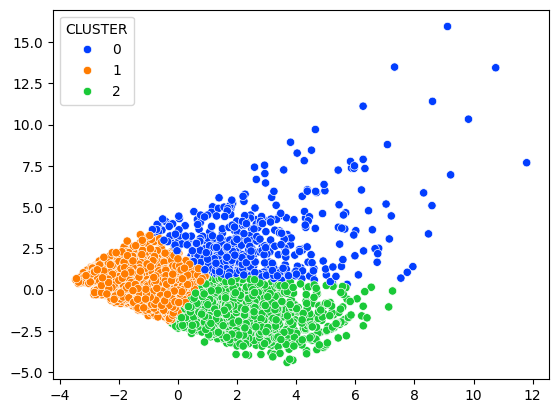

In [185]:
# Cluster visualization in 2D

pca_2d = PCA(n_components=3)
pca_2d.fit(df_scaled)

sales_scaled_pca_2d = pca_2d.fit_transform(df_scaled)

sns.scatterplot(x=sales_scaled_pca_2d[:,0], y=sales_scaled_pca_2d[:,1], hue=df['CLUSTER'], palette='bright')

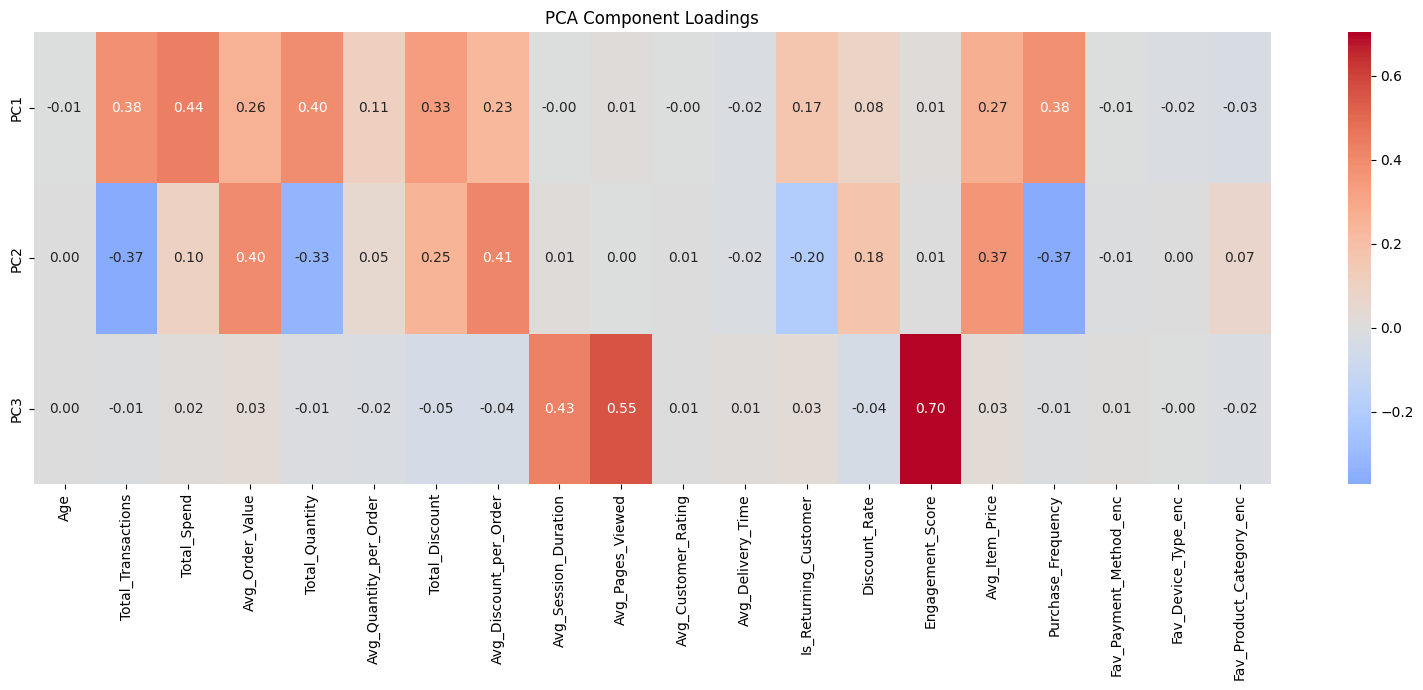

In [175]:
# PCA Loading Matrix for 4 PC's 
pca_components = pd.DataFrame(
    pca.components_,
    columns=df.drop(columns='CLUSTER').columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Heatmap
plt.figure(figsize=(16, 7))
sns.heatmap(pca_components, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA Component Loadings')
plt.tight_layout()
plt.show()

In [176]:
df.groupby('CLUSTER').mean().round(2).T

CLUSTER,0,1,2
Age,34.49,35.17,34.95
Total_Transactions,2.74,2.01,5.55
Total_Spend,8555.28,1462.05,6152.49
Avg_Order_Value,4328.61,732.18,1234.88
Total_Quantity,9.00,5.77,16.72
Avg_Quantity_per_Order,3.40,2.90,3.14
Total_Discount,834.50,64.18,306.13
Avg_Discount_per_Order,317.06,30.77,53.68
Avg_Session_Duration,14.59,14.55,14.52
Avg_Pages_Viewed,9.01,8.97,9.03


In [177]:
df['CLUSTER'].value_counts().sort_index()

CLUSTER
0     540
1    3067
2    1217
Name: count, dtype: int64

In [178]:
#Create pipeline that contains scaler, PCA and KMeans
pipeline_kmeans = Pipeline([
    ('scaler', scaler),        
    ('pca', pca),              
    ('kmeans', km)             
])

# Save pipeline
with open('model_clustering.pkl', 'wb') as file:
    pickle.dump(pipeline_kmeans, file)

In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4824 entries, 0 to 4823
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       4824 non-null   int64  
 1   Total_Transactions        4824 non-null   int64  
 2   Total_Spend               4824 non-null   float64
 3   Avg_Order_Value           4824 non-null   float64
 4   Total_Quantity            4824 non-null   int64  
 5   Avg_Quantity_per_Order    4824 non-null   float64
 6   Total_Discount            4824 non-null   float64
 7   Avg_Discount_per_Order    4824 non-null   float64
 8   Avg_Session_Duration      4824 non-null   float64
 9   Avg_Pages_Viewed          4824 non-null   float64
 10  Avg_Customer_Rating       4824 non-null   float64
 11  Avg_Delivery_Time         4824 non-null   float64
 12  Is_Returning_Customer     4824 non-null   int32  
 13  Discount_Rate             4824 non-null   float64
 14  Engageme

In [180]:
df.columns

Index(['Age', 'Total_Transactions', 'Total_Spend', 'Avg_Order_Value',
       'Total_Quantity', 'Avg_Quantity_per_Order', 'Total_Discount',
       'Avg_Discount_per_Order', 'Avg_Session_Duration', 'Avg_Pages_Viewed',
       'Avg_Customer_Rating', 'Avg_Delivery_Time', 'Is_Returning_Customer',
       'Discount_Rate', 'Engagement_Score', 'Avg_Item_Price',
       'Purchase_Frequency', 'Fav_Payment_Method_enc', 'Fav_Device_Type_enc',
       'Fav_Product_Category_enc', 'CLUSTER'],
      dtype='object')

In [181]:
# ── CLUSTER PROFILING ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Pastikan df sudah ada kolom CLUSTER dari step sebelumnya
# Kalau belum, refit dulu:
# df['CLUSTER'] = km_final.fit_predict(df_pca_final)

# ── 1. STATISTIK DESKRIPTIF per CLUSTER ──────────────────────────────────────
numeric_cols = [
    # Spending behavior
    'Total_Transactions',      # seberapa sering beli
    'Total_Spend',             # total belanja keseluruhan
    'Avg_Order_Value',         # rata-rata belanja per transaksi
    'Avg_Item_Price',          # harga item yang biasa dibeli
    
    # Engagement
    'Avg_Session_Duration',    # rata-rata lama browsing
    'Avg_Pages_Viewed',        # rata-rata halaman dilihat
    'Engagement_Score',        # gabungan session x pages
    
    # Kepuasan & loyalitas
    'Avg_Customer_Rating',     # kepuasan rata-rata
    'Avg_Delivery_Time',       # pengalaman delivery
    'Is_Returning_Customer',   # pernah balik beli lagi
    
    # Price sensitivity
    'Discount_Rate',           # seberapa sering pakai diskon
]

profile = df.groupby('CLUSTER')[numeric_cols].mean().round(2)
print("=" * 70)
print("CLUSTER PROFILING — MEAN per CLUSTER")
print("=" * 70)
print(profile.T.to_string())
print("=" * 70)

# Ukuran tiap cluster
size = df['CLUSTER'].value_counts().sort_index()
pct  = (size / len(df) * 100).round(1)
print("\nDistribusi Cluster:")
for c in size.index:
    print(f"  Cluster {c}: {size[c]:,} data ({pct[c]}%)")

CLUSTER PROFILING — MEAN per CLUSTER
CLUSTER                      0        1        2
Total_Transactions        2.74     2.01     5.55
Total_Spend            8555.28  1462.05  6152.49
Avg_Order_Value        4328.61   732.18  1234.88
Avg_Item_Price          949.78   264.68   394.16
Avg_Session_Duration     14.59    14.55    14.52
Avg_Pages_Viewed          9.01     8.97     9.03
Engagement_Score        131.20   129.94   131.09
Avg_Customer_Rating       3.90     3.90     3.90
Avg_Delivery_Time         6.33     6.59     6.49
Is_Returning_Customer     0.92     0.87     1.00
Discount_Rate             0.08     0.05     0.05

Distribusi Cluster:
  Cluster 0: 540 data (11.2%)
  Cluster 1: 3,067 data (63.6%)
  Cluster 2: 1,217 data (25.2%)


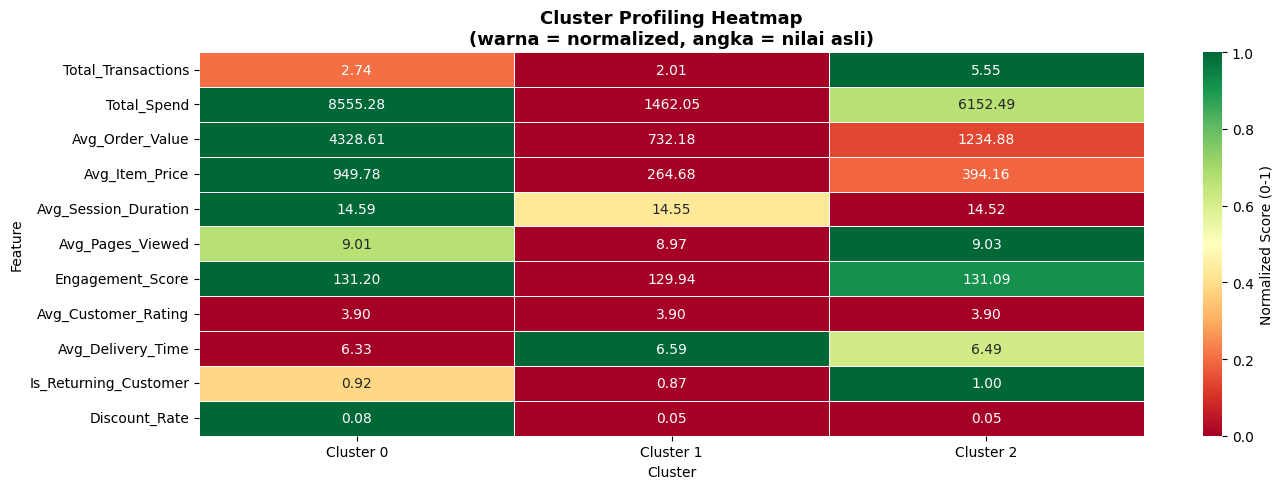

In [182]:
# ── 2. HEATMAP PROFILING ──────────────────────────────────────────────────────
# Normalisasi 0-1 biar semua fitur bisa dibanding dalam 1 heatmap
from sklearn.preprocessing import MinMaxScaler


scaler_viz = MinMaxScaler()
profile_norm = pd.DataFrame(
    scaler_viz.fit_transform(profile),
    index=profile.index,
    columns=profile.columns
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(profile_norm.T,
            annot=profile.T,           # tampilkan nilai asli
            fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Normalized Score (0-1)'})

ax.set_title('Cluster Profiling Heatmap\n(warna = normalized, angka = nilai asli)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
ax.set_xticklabels([f'Cluster {i}' for i in profile.index], rotation=0)

plt.tight_layout()
plt.savefig('cluster_profiling_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [183]:
# Cek dulu mana fitur yang paling berbeda antar cluster
profile_range = profile[numeric_cols].max() - profile[numeric_cols].min()
print("Range antar cluster (makin besar = makin distinct):")
print(profile_range.sort_values(ascending=False).round(2))

Range antar cluster (makin besar = makin distinct):
Total_Spend              7093.23
Avg_Order_Value          3596.43
Avg_Item_Price            685.10
Total_Transactions          3.54
Engagement_Score            1.26
Avg_Delivery_Time           0.26
Is_Returning_Customer       0.13
Avg_Session_Duration        0.07
Avg_Pages_Viewed            0.06
Discount_Rate               0.03
Avg_Customer_Rating         0.00
dtype: float64


Nilai normalized — cek apakah Cluster 0 tidak selalu rendah:
         Total_Spend  Avg_Order_Value  Total_Transactions  Avg_Item_Price  \
CLUSTER                                                                     
0              1.000             1.00               0.206           1.000   
1              0.000             0.00               0.000           0.000   
2              0.661             0.14               1.000           0.189   

         Is_Returning_Customer  Discount_Rate  
CLUSTER                                        
0                        0.385            1.0  
1                        0.000            0.0  
2                        1.000            0.0  


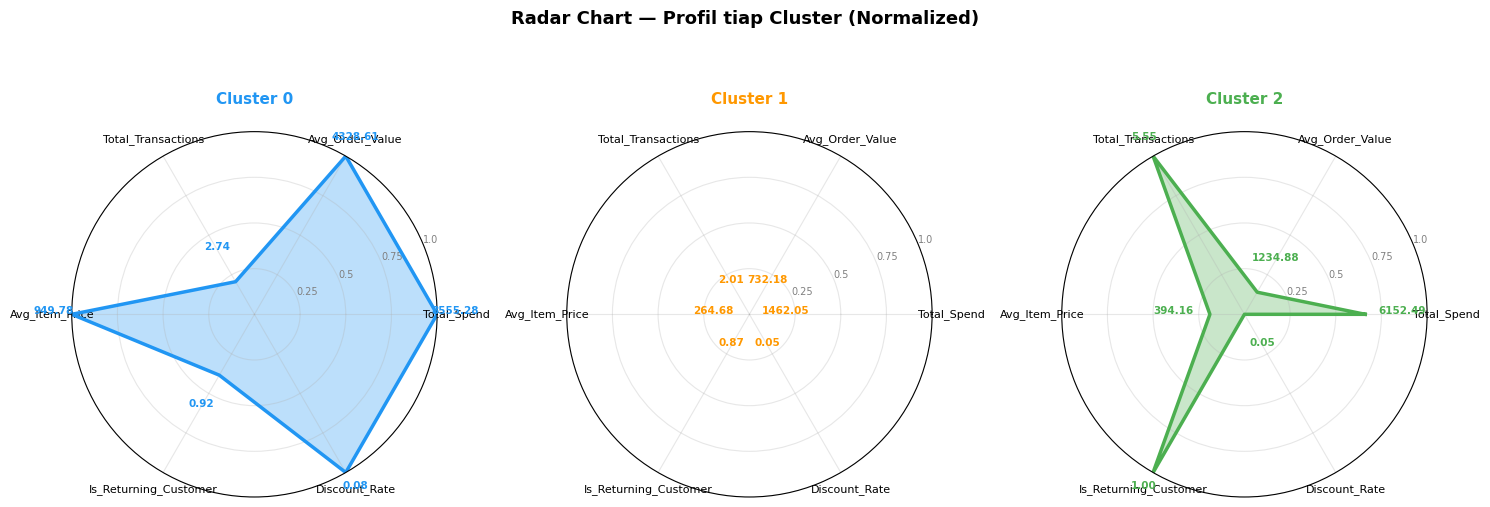

In [184]:
# ── RADAR CHART FIXED — dengan normalisasi benar ─────────────────────────────
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

# ── RADAR CHART FIXED v2 ──────────────────────────────────────────────────────
radar_cols = [
    'Total_Spend',
    'Avg_Order_Value', 
    'Total_Transactions',
    'Avg_Item_Price',
    'Is_Returning_Customer',
    'Discount_Rate',
]

radar_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(profile[radar_cols]),
    index=profile.index,
    columns=radar_cols
)

print("Nilai normalized — cek apakah Cluster 0 tidak selalu rendah:")
print(radar_norm.round(3))

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

colors        = ['#2196F3', '#FF9800', '#4CAF50']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 3, figsize=(15, 6),
                          subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart — Profil tiap Cluster (Normalized)',
             fontsize=13, fontweight='bold')

for idx, (ax, color, name) in enumerate(zip(axes, colors, cluster_names)):
    values = radar_norm.loc[idx].tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.3)

    # Annotate nilai asli
    original_vals = profile[radar_cols].loc[idx].tolist()
    for angle, val_norm, val_ori in zip(angles[:-1], values[:-1], original_vals):
        ax.annotate(f'{val_ori:.2f}',
                    xy=(angle, val_norm),
                    xytext=(angle, min(val_norm + 0.2, 1.1)),
                    fontsize=7.5, ha='center', color=color, fontweight='bold')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_cols, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(name, size=11, fontweight='bold', color=color, pad=20)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=7, color='gray')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_radar_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [186]:
cluster_names = {
    0: "Premium Buyer",      # spend tertinggi, item mahal, jarang tapi royal
    1: "Casual Buyer",       # mayoritas, spend rendah, jarang balik
    2: "Loyal Frequent Buyer" # sering beli, 100% returning, mid-range spend
}

cluster_strategy = {
    0: [
        "Exclusive VIP membership & early access produk premium",
        "Personal shopper / dedicated customer service",
        "Reward berbasis total spend — cashback atau poin premium",
        "Undangan ke private sale atau event eksklusif"
    ],
    1: [
        "Re-engagement campaign — email/push notif dengan promo menarik",
        "Bundle produk entry-level untuk naikkan order value",
        "Program onboarding loyalty — dorong jadi returning customer",
        "Flash sale & limited time offer untuk trigger pembelian"
    ],
    2: [
        "Loyalty points yang makin besar seiring frekuensi beli",
        "Subscription / auto-reorder untuk produk favorit",
        "Cross-sell & upsell produk yang lebih premium",
        "Referral program — customer loyal = brand ambassador terbaik"
    ]
}